In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/spotify_tracks_clean.csv")

# remove broken tracks, spoken word and comedy
bad = (
    (df["tempo"] == 0) | (df["time_signature"] == 0)
    | (df["duration_ms"] < 30_000) | (df["duration_ms"] > 900_000)
    | (df["loudness"] < -35)
    | (df["speechiness"] > 0.8)
    | df["all_genres"].str.contains("comedy", case=False, na=False)
)
df = df[~bad].reset_index(drop=True)

features = ["danceability", "energy", "acousticness", "instrumentalness",
            "liveness", "speechiness", "valence", "tempo", "loudness",
            "key_sin", "key_cos", "mode"]

X = df[features].copy()
X["instrumentalness"] = X["instrumentalness"].where(X["instrumentalness"] > 0.05, 0.0)
X["speechiness"] = np.log(X["speechiness"] + 0.01)
X["liveness"] = np.log(X["liveness"] + 0.01)
X["loudness"] = X["loudness"].clip(lower=-25)

weights = {"danceability": 1.0, "energy": 1.0, "acousticness": 1.0,
           "instrumentalness": 1.0, "valence": 1.0, "tempo": 0.8, "loudness": 0.7,
           "speechiness": 0.7, "liveness": 0.4,
           "key_sin": 0.3, "key_cos": 0.3, "mode": 0.4}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) * np.array([weights[f] for f in features])

df.to_csv("data/spotify_tracks_final.csv", index=False)
np.save("data/X_scaled.npy", X_scaled)
joblib.dump(scaler, "data/scaler.joblib")
print(df.shape, X_scaled.shape)   # the two row counts must match

(79108, 25) (79108, 12)


In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/spotify_tracks_clean.csv")   # always start from the clean file
print("start:", df.shape)

features = ["danceability", "energy", "acousticness", "instrumentalness",
            "liveness", "speechiness", "valence", "tempo", "loudness",
            "key_sin", "key_cos", "mode"]

# Check what the high-speechiness rows are BEFORE dropping them
print(df[df["speechiness"] > 0.8][["track_name", "artists"]].sample(10, random_state=1))

start: (80152, 25)
                                      track_name                      artists
61314                        Youngest Kid (Live)               Andrew Norelli
55167                                 Covid Mask  Jim Florentine;Don Jamieson
51211                              You Need Weed                Katt Williams
55948                                  Underwear               Chris Robinson
56045  Narcissism and the Slow March to Oblivion                  David Cross
59938                           Meats and Robots                   Myq Kaplan
62935                                        Ftp                 George Lopez
54654                    Mexicans in an Elevator               Bert Kreischer
60463                    Roaster Chicken (Redux)                   Jeff Allen
62812                                      Logic                   Ryan Stout


In [2]:
df = df[df["speechiness"] <= 0.8].reset_index(drop=True)
print("after speechiness filter:", df.shape)

after speechiness filter: (79368, 25)


In [3]:
# how many comedy rows are left after the speechiness cut?
is_comedy = df["all_genres"].str.contains("comedy", case=False, na=False)
print("comedy rows remaining:", is_comedy.sum())
print(df[is_comedy][["track_name", "artists", "speechiness"]].sample(8, random_state=1))

comedy rows remaining: 260
                                              track_name              artists  \
52779                        All in Together (GnT Remix)  Professor Elemental   
60395                                        Liquored Up           Tom Cotter   
57779                       Lesbians Love Whale Watching         Margaret Cho   
53861  Trapped In the Drive-Thru (Parody of "Trapped ...  "Weird Al" Yankovic   
57557                                            Detroit     Kathleen Madigan   
58786                                   Fit Bit / Ambien     Kathleen Madigan   
50231                                His Cock's Got Ribs  Kevin Bloody Wilson   
62197                                    Weird Sex Moves           Louis Katz   

       speechiness  
52779        0.279  
60395        0.757  
57779        0.489  
53861        0.088  
57557        0.744  
58786        0.574  
50231        0.297  
62197        0.731  


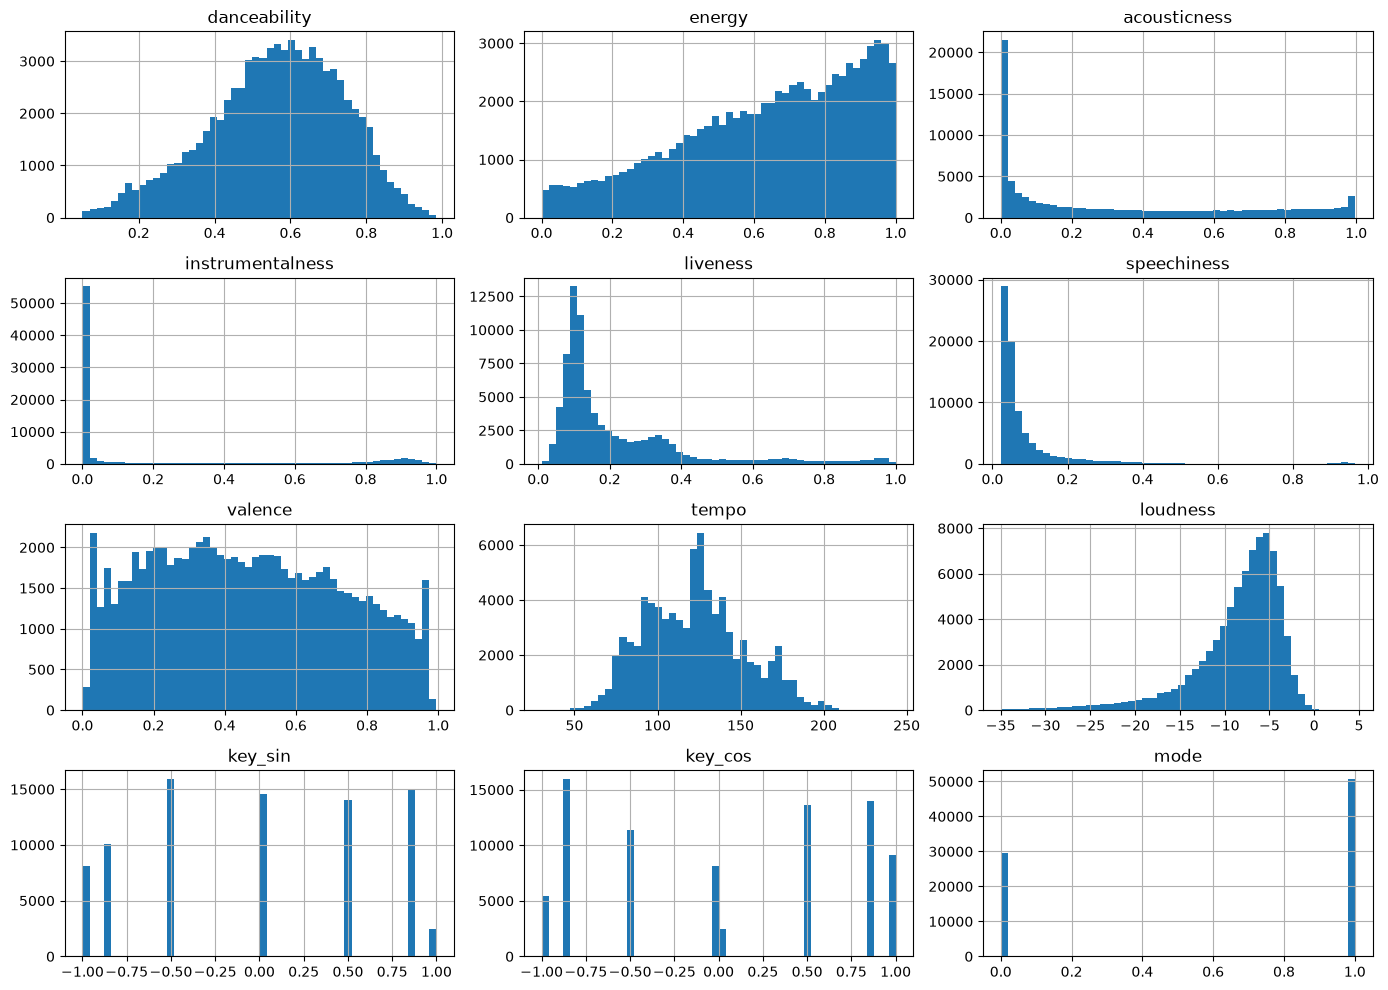

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, QuantileTransformer

df = pd.read_csv("data/spotify_tracks_clean.csv")

features = ["danceability", "energy", "acousticness", "instrumentalness",
            "liveness", "speechiness", "valence", "tempo", "loudness",
            "key_sin", "key_cos", "mode"]

# 1. Look at the shapes first
df[features].hist(bins=50, figsize=(14, 10))
plt.tight_layout(); plt.show()

# 2. Fix the skewed columns
skewed = ["instrumentalness", "speechiness", "liveness"]
qt = QuantileTransformer(output_distribution="uniform", random_state=0)
df[skewed] = qt.fit_transform(df[skewed])

# 3. Scale everything
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

array([[<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'loudness'}>],
       [<Axes: title={'center': 'key_sin'}>,
        <Axes: title={'center': 'key_cos'}>,
        <Axes: title={'center': 'mode'}>]], dtype=object)

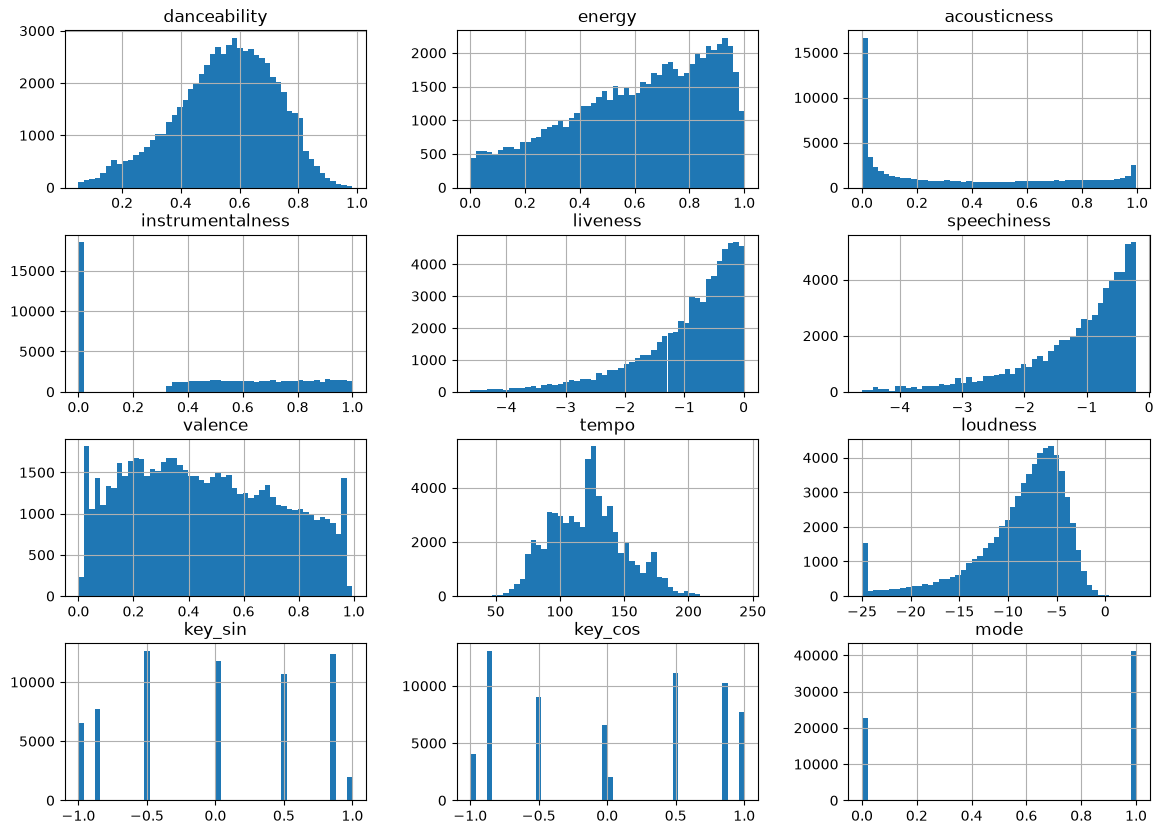

In [2]:
df = df[df["speechiness"] <= 0.8].reset_index(drop=True)

X = df[features].copy()

# instrumentalness: values this small are noise, so treat them as 0
X["instrumentalness"] = X["instrumentalness"].where(X["instrumentalness"] > 0.05, 0.0)

# log-transform the right-skewed columns
X["speechiness"] = np.log(X["speechiness"] + 0.01)
X["liveness"] = np.log(X["liveness"] + 0.01)

# tame the loudness tail
X["loudness"] = X["loudness"].clip(lower=-25)

# check the result
X.hist(bins=50, figsize=(14, 10))

In [4]:

import joblib
weights = {
    "danceability": 1.0, "energy": 1.0, "acousticness": 1.0,
    "instrumentalness": 1.0, "valence": 1.0, "tempo": 0.8, "loudness": 0.7,
    "speechiness": 0.7, "liveness": 0.4,
    "key_sin": 0.3, "key_cos": 0.3, "mode": 0.4,
}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled * np.array([weights[f] for f in features])

# save everything for notebook 03
df.to_csv("data/spotify_tracks_final.csv", index=False)
np.save("data/X_scaled.npy", X_scaled)
joblib.dump(scaler, "data/scaler.joblib")

['data/scaler.joblib']

In [5]:
print(df.shape)
print(df["speechiness"].describe())

(63871, 25)
count    63871.000000
mean         0.400120
std          0.231373
min          0.000000
25%          0.198198
50%          0.400901
75%          0.599315
max          0.799800
Name: speechiness, dtype: float64
